In [1]:

import pandas as pd
import numpy as numpy

pd.set_option("display.max_columns", None)

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_merged = pd.read_csv("data/merged_customer_flight_loyalty.csv")

## Fase 2 - Análisis estadístico
### 1. Análisis variables numéricas

In [4]:
def basic_exploration(df):
    display(df.head(2))
    display(df.tail(2))
    display(df.sample(2))
    print(df.info())
    print(f"El dataframe {df} tiene {df.shape[0]} filas y {df.shape[1]} columnas")

In [ ]:
basic_exploration(df_merged)

In [31]:
def descriptive_analysis(df):
    print("NUMÉRICAS")
    display(df.describe(include="number").T)
    print("CATEGÓRICAS")
    display(df.describe(include="object").T)

In [32]:
descriptive_analysis(df_merged)

NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
loyalty_number,403760.0,549875.383713,258961.514684,100018.00,326699.00,550598.00,772152.00,999986.00
year,403760.0,2017.500352,0.500000,2017.00,2017.00,2018.00,2018.00,2018.00
flights_booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00
flights_with_companions,403760.0,1.036569,2.080472,0.00,0.00,0.00,1.00,11.00
total_flights,403760.0,5.170619,6.526858,0.00,0.00,1.00,10.00,32.00
distance,403760.0,1214.460979,1434.098521,0.00,0.00,525.00,2342.00,6293.00
points_accumulated,403760.0,124.263761,146.696179,0.00,0.00,53.00,240.00,676.50
points_redeemed,403760.0,30.838587,125.758002,0.00,0.00,0.00,0.00,876.00
dollar_cost_points_redeemed,403760.0,2.495973,10.172033,0.00,0.00,0.00,0.00,71.00
salary,403760.0,77932.277863,30076.538315,15609.00,64001.00,73510.00,82940.00,407228.00


CATEGÓRICAS


,count,unique,top,freq
month,403760,12,Noviembre,33663
country,403760,1,Canada,403760
province,403760,11,Ontario,130258
city,403760,29,Toronto,80775
postal_code,403760,55,V6E 3D9,21944
gender,403760,2,Female,202757
education,403760,5,Bachelor,252567
marital_status,403760,3,Married,234845
loyalty_card,403760,3,Star,183745
enrollment_type,403760,2,Standard,380419


Hay una diferencia significativa entre la media y mediana de varias columnas como flights_booked, distance, total_flights, points_accumulated y points_redeemed, que se debe a que hay un número pequeño de clientes que reservan más vuelos y canjean más puntos. Esto provoca que la distribución está sesgada a la derecha porque la mayoría de los clientes no reservan vuelos ni canjean puntos aunque están dados de alta como usuarios.

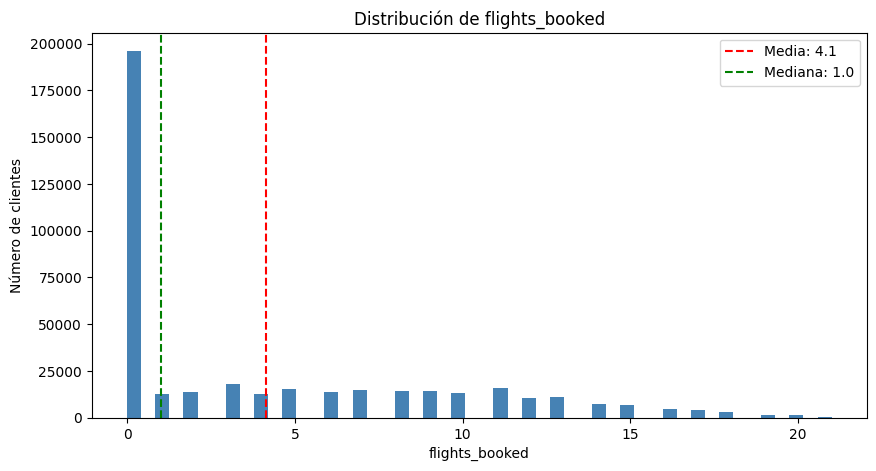

In [37]:
col = 'flights_booked'

plt.figure(figsize=(10, 5))
plt.hist(df_merged[col], bins=50, color='steelblue')

plt.axvline(df_merged[col].mean(),   color='red',   linestyle='--', label=f'Media: {df_merged[col].mean():.1f}')
plt.axvline(df_merged[col].median(), color='green', linestyle='--', label=f'Mediana: {df_merged[col].median():.1f}')

plt.title(f'Distribución de {col}')
plt.xlabel(col)
plt.ylabel('Número de clientes')
plt.legend()
plt.show()

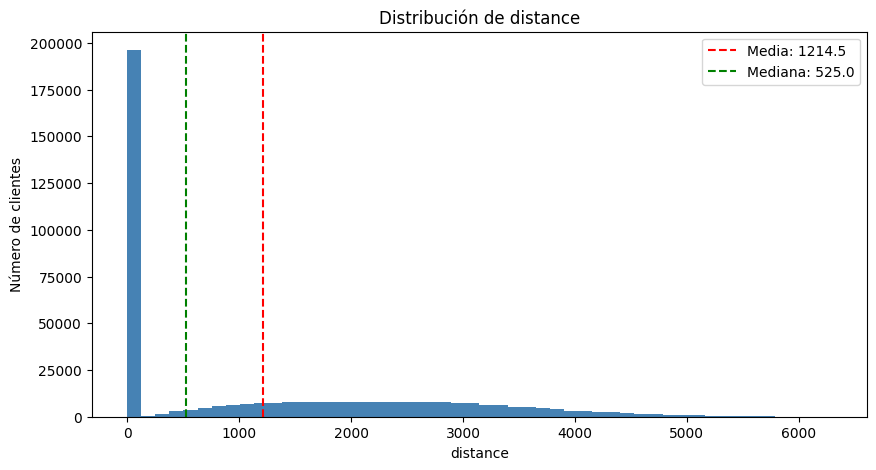

In [23]:
col = 'distance'

plt.figure(figsize=(10, 5))
plt.hist(df_merged[col], bins=50, color='steelblue')

plt.axvline(df_merged[col].mean(),   color='red',   linestyle='--', label=f'Media: {df_merged[col].mean():.1f}')
plt.axvline(df_merged[col].median(), color='green', linestyle='--', label=f'Mediana: {df_merged[col].median():.1f}')

plt.title(f'Distribución de {col}')
plt.xlabel(col)
plt.ylabel('Número de clientes')
plt.legend()
plt.show()

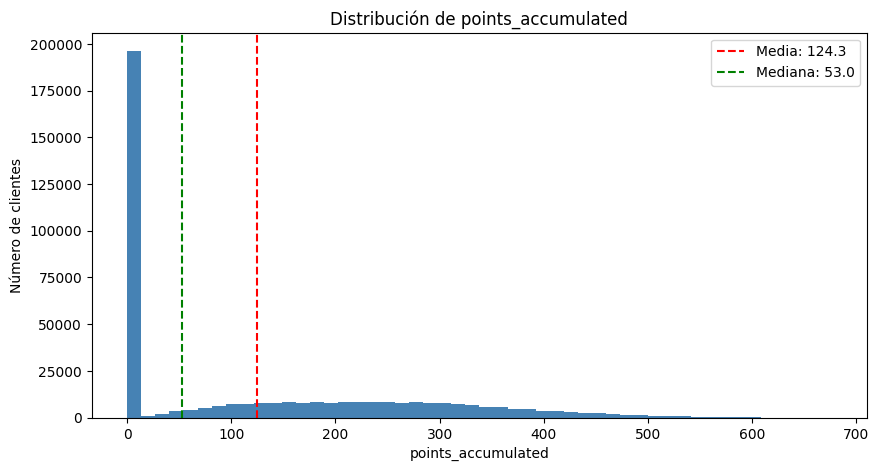

In [ ]:
col = 'points_accumulated'

plt.figure(figsize=(10, 5))
plt.hist(df_merged[col], bins=50, color='steelblue')

plt.axvline(df_merged[col].mean(),   color='red',   linestyle='--', label=f'Media: {df_merged[col].mean():.1f}')
plt.axvline(df_merged[col].median(), color='green', linestyle='--', label=f'Mediana: {df_merged[col].median():.1f}')

plt.title(f'Distribución de {col}')
plt.xlabel(col)
plt.ylabel('Número de clientes')
plt.legend()
plt.show()

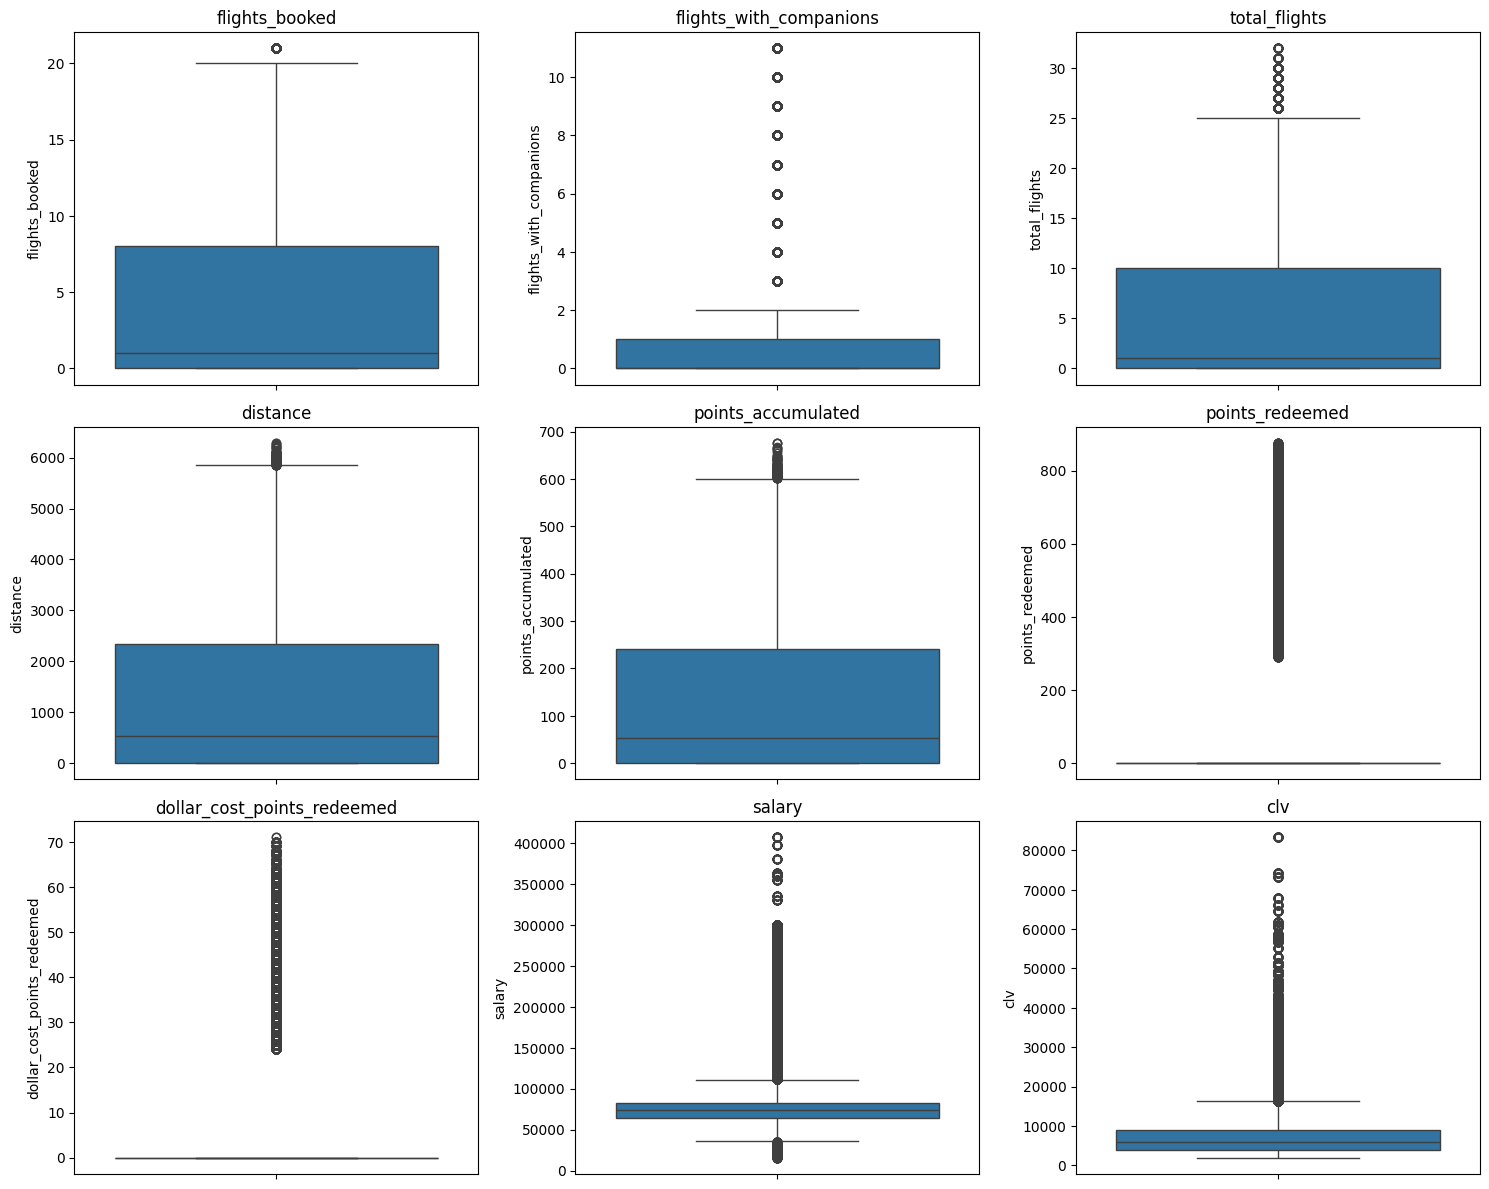

In [35]:
columns_num = df_merged[["flights_booked", "flights_with_companions", "total_flights", "distance", "points_accumulated", "points_redeemed", "dollar_cost_points_redeemed", "salary", "clv"]]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(columns_num):
    sns.boxplot(y=df_merged[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Los gráficos de distancia y puntos (distance, points_accumulated) muestran que la mayoría de los usuarios usa poco el servicio y unos pocos lo usan mucho.
Los datos de points_redeemed y distance señalan esta diferencia más aún, pudiéndose ver que la mayoría no redime puntos y unos pocos redimen cantidades muy grandes.
El gráfico de dollar_cost_points_redeemed sugiere que hay un grupo específico de usuarios que redimen puntos en dinero.
Los datos de salary y clv muestran datos de salarios muy extremos, puede que de directores o ejecutivos de la empresa.

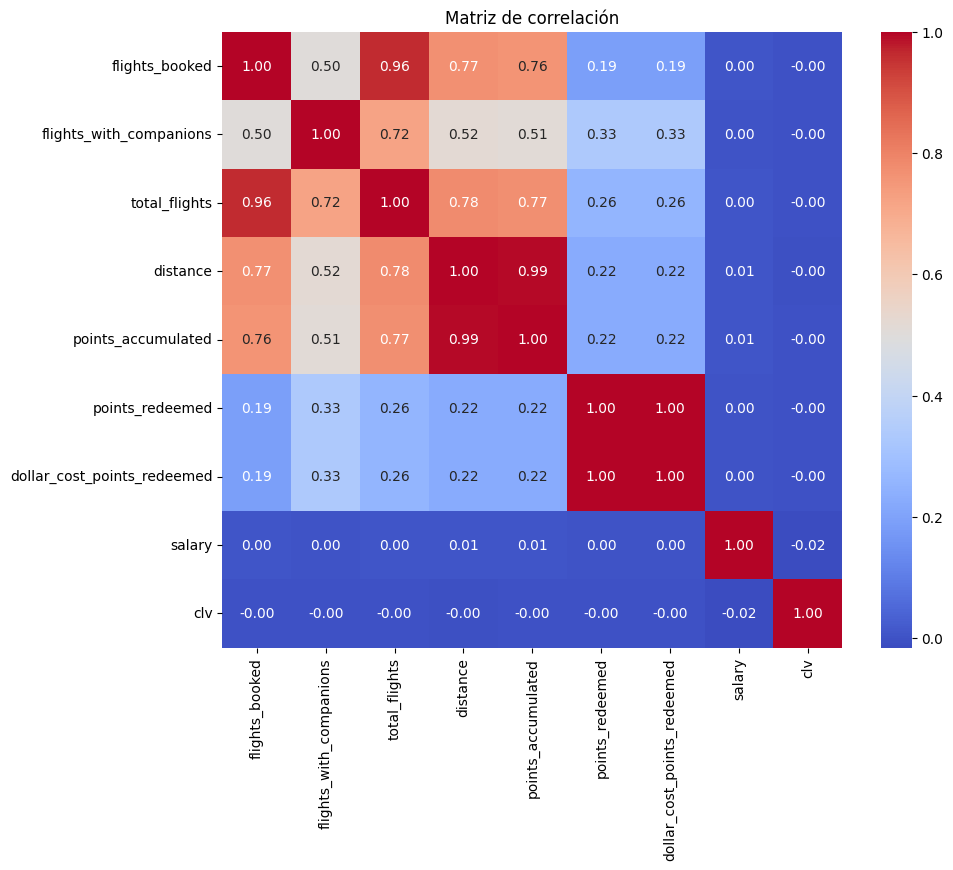

In [36]:
correlation = columns_num.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

Los registros de distance y points_accumulated tienen una alta correlación, ya que cuanto más se vuela más puntos se acumulan.
Lo mismo sucede con flights_booked y total_flights y points_redeemed y dollar_cost_points_redeemed, respectivamente
Por otro lado, flights_booked, total_flights, distance y points_accumulated están correlacionado entre sí formando un grupo que representa la actividad de vuelo.

Por último, salary y clv no correlacionan con nada y son independientes del comportamiento de vuelo.

In [38]:
columnas_categoricas = ['gender', 'education', 'marital_status', 
                        'loyalty_card', 'enrollment_type']

for col in columnas_categoricas:
    print(f"\n{col}:")
    print(df_merged[col].value_counts())


gender:
gender
Female    202757
Male      201003
Name: count, dtype: int64

education:
education
Bachelor                252567
College                 102260
High School or Below     18915
Doctor                   17731
Master                   12287
Name: count, dtype: int64

marital_status:
marital_status
Married     234845
Single      108153
Divorced     60762
Name: count, dtype: int64

loyalty_card:
loyalty_card
Star      183745
Nova      136883
Aurora     83132
Name: count, dtype: int64

enrollment_type:
enrollment_type
Standard          380419
2018 Promotion     23341
Name: count, dtype: int64


Los datos representan a poco más de 400.000 registros y presentan una distribución de género casi perfectamente equilibrada.
En cuanto a educación, existe un sesgo marcado hacia perfiles con estudios universitarios (Bachelor representa casi el 63%).
El estado civil muestra una mayoría de casados (58%), seguido de solteros y divorciados.
Enrollment type tiene muy poca varianza al ser Standard el 94% de los casos.